In [124]:
# Installing Stuff
!pip install librosa --quiet
!pip install torchinfo --quiet
!pip install torchinfo seaborn --quiet

In [ ]:
# Dependencies
import os
import re
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torchvision.models as models
from torchvision.models import EfficientNet_B0_Weights
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, multilabel_confusion_matrix

In [ ]:
# Using Colab GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU Name   : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU found. Go to Runtime > Change runtime type > GPU")

Using device: cuda
GPU Name   : Tesla T4
GPU Memory : 15.6 GB


In [ ]:
CLASSES = [
    "Asthma",               # index 0  — ICBHI + your filenames + lung dataset
    "Heart Failure",        # index 1  — your filenames + ICBHI
    "COPD",                 # index 2  — ICBHI + your filenames
    "Pneumonia",            # index 3  — ICBHI + your filenames + lung dataset
    "Pleural Effusion",     # index 4  — your filenames + ICBHI
    "Lung Fibrosis",        # index 5  — your filenames + ICBHI
    "Bronchitis",           # index 6  — your filenames (BRON)
    "Bronchiectasis",       # index 7  — ICBHI only
    "Bronchiolitis",        # index 8  — ICBHI only
    "URTI",                 # index 9  — ICBHI only (Upper Respiratory Tract Infection)
    "Normal",               # index 10 — ICBHI + your filenames (N) + lung dataset
    "None",                 # index 11 — your filenames
]

NUM_CLASSES = len(CLASSES)
print(f"{NUM_CLASSES} classes (multi-label — images can have multiple active classes):")
for i, cls in enumerate(CLASSES):
    print(f"  [{i:>2}] {cls}")

12 classes (multi-label — images can have multiple active classes):
  [ 0] Asthma
  [ 1] Heart Failure
  [ 2] COPD
  [ 3] Pneumonia
  [ 4] Pleural Effusion
  [ 5] Lung Fibrosis
  [ 6] Bronchitis
  [ 7] Bronchiectasis
  [ 8] Bronchiolitis
  [ 9] URTI
  [10] Normal
  [11] None


In [134]:
# Parse file names into interpretable values

CLASSES = [
    "Asthma",               # index 0
    "Heart Failure",        # index 1
    "COPD",                 # index 2
    "Pneumonia",            # index 3
    "Pleural Effusion",     # index 4
    "Lung Fibrosis",        # index 5
    "Bronchitis",           # index 6
    "Bronchiectasis",       # index 7
    "Bronchiolitis",        # index 8
    "URTI",                 # index 9
    "Normal",               # index 10
    "None",                 # index 11
]

NUM_CLASSES = len(CLASSES)


def parse_multilabel_vector(filename):
    """
    Parse a filename into a multi-label vector.

    Filename format:
        {record_id}_{idx}_{age_int}_{age_decimal}_{gender}_{diagnosis}_{aug}.png
    Example:
        DP14_0_54_0_M_Heart Failure + COPD_orig.png

    Returns:
        label_vector   : torch.Tensor of shape (NUM_CLASSES,) with 0.0/1.0 values
        matched_classes: list of matched class name strings
        raw_label      : the lowercased diagnosis string extracted from the filename
                         (useful for debugging skipped files)

    Returns (None, [], raw_label) if:
        - filename has too few underscore-separated fields
        - diagnosis field is empty
        - no known class could be matched
    """
    name  = os.path.splitext(filename)[0]   # strip extension
    parts = name.split('_', 6)              # max 6 splits → up to 7 parts

    # Need at least 5 parts to reach index 5 (the diagnosis field)
    if len(parts) < 5:
        return None, [], name

    # Extract and normalise the diagnosis field
    raw_label = parts[4].replace('_', ' ').lower().strip()
    if not raw_label:
        return None, [], ""

    label_vector    = torch.zeros(NUM_CLASSES, dtype=torch.float32)
    matched_classes = []

    def add(cls_name):
        """Flip the slot for cls_name to 1 and record it."""
        idx = CLASSES.index(cls_name)
        label_vector[idx] = 1.0
        if cls_name not in matched_classes:
            matched_classes.append(cls_name)

    # ── Matching: if the substring appears anywhere in the label, activate it.
    # More-specific terms are checked before shorter substrings that could
    # be contained within them (e.g. "bronchiectasis" before "bron").
    # All checks are independent `if` statements so multiple classes can match
    # in a single filename (multi-label support).

    if "bronchiectasis" in raw_label:   add("Bronchiectasis")
    if "bronchiolitis"  in raw_label:   add("Bronchiolitis")
    if "bronchitis"     in raw_label:   add("Bronchitis")
    if "bron"           in raw_label:   add("Bronchitis")       # abbreviation
    if "heart"  in raw_label:   add("Heart Failure")
    if "lung"  in raw_label:   add("Lung Fibrosis")
    if "pleural"  in raw_label: add("Pleural Effusion")
    if "plueral"  in raw_label: add("Pleural Effusion") # common misspelling
    if "pneumonia"      in raw_label:   add("Pneumonia")
    if "urti"           in raw_label:   add("URTI")
    if "copd"           in raw_label:   add("COPD")
    if "asthma"         in raw_label:   add("Asthma")
    if "healthy"        in raw_label:   add("Normal")
    if "none"           in raw_label:   add("None")
    if raw_label == "n":                add("Normal")            # exact abbreviation only
    if "normal"         in raw_label:   add("Normal")

    # Nothing matched — caller should skip this file
    if label_vector.sum() == 0:
        return None, [], raw_label

    return label_vector, matched_classes, raw_label


def parse_age_gender(filename):
    """
    Extract age and gender from a filename.

    Filename format:
        {record_id}_{idx}_{age_int}_{age_decimal}_{gender}_{diagnosis}_{aug}.png

    Returns:
        age_norm : float — age normalised to [0, 1] by dividing by 100
        gender   : float — 1.0 for Male, 0.0 for Female
    Falls back to (0.5, 0.5) on any parse error.
    """
    try:
        name     = os.path.splitext(filename)[0]
        parts    = name.split('_', 6)
        age_norm = float(f"{parts[2]}.{parts[3]}") / 100.0
        gender   = 1.0 if parts[4].upper() == 'M' else 0.0
        return age_norm, gender
    except (ValueError, IndexError):
        return 0.5, 0.5
def parse_age_gender(filename):
    """
    Format: {record_id}_{idx}_{age_int}_{age_decimal}_{gender}_{diagnosis}_{aug_name}
    age   = fields [2].[3] joined back into float, normalised by /100
    gender = field [4]: M=1.0, F=0.0
    """
    try:
        name  = os.path.splitext(filename)[0]
        parts = name.split('_', 6)
        age_norm = float(f"{parts[2]}.{parts[3]}") / 100.0
        gender   = 1.0 if parts[4].upper() == 'M' else 0.0
        return age_norm, gender
    except (ValueError, IndexError):
        return 0.5, 0.5

In [132]:
# Test parser
test_files = [
    # {record_id}_{age}_{gender}_{diagnosis}_{aug_name}
    "DP14_54_M_Heart Failure_orig.png",
    "DP77_40_M_Asthma_orig.png",
    "DP71_71_M_Heart Failure + COPD_orig.png",
    "DP90_90_M_Asthma and lung fibrosis_aug1.png",
    "DP72_72_F_Heart Failure + Lung Fibrosis_aug2.png",
    "DP81_81_M_Plueral Effusion_orig.png",
    "DP57_57_M_pneumonia_orig.png",
    "DP18_18_F_N_orig.png",
    "DP20_20_M_BRON_aug1.png",
]

print("Multi-label parser test -- {record_id}_{age}_{gender}_{diagnosis}_{aug_name}:")
print(f"{'Filename':<55} {'Vec':<15} {'Active Classes'}")
print("-" * 100)
for f in test_files:
    vec, classes, raw = parse_multilabel_vector(f)
    if vec is not None:
        active = ", ".join(classes) if classes else "NONE MATCHED"
        vec_str = "".join(str(int(v)) for v in vec.tolist())
        print(f"  {f:<55} [{vec_str}]  {active}")
    else:
        print(f"  {f:<55} ✗ SKIPPED — could not parse '{raw}'")

Multi-label parser test -- {record_id}_{age}_{gender}_{diagnosis}_{aug_name}:
Filename                                                Vec             Active Classes
----------------------------------------------------------------------------------------------------
  DP14_54_M_Heart Failure_orig.png                        ✗ SKIPPED — could not parse 'orig'
  DP77_40_M_Asthma_orig.png                               ✗ SKIPPED — could not parse 'orig'
  DP71_71_M_Heart Failure + COPD_orig.png                 ✗ SKIPPED — could not parse 'orig'
  DP90_90_M_Asthma and lung fibrosis_aug1.png             ✗ SKIPPED — could not parse 'aug1'
  DP72_72_F_Heart Failure + Lung Fibrosis_aug2.png        ✗ SKIPPED — could not parse 'aug2'
  DP81_81_M_Plueral Effusion_orig.png                     ✗ SKIPPED — could not parse 'orig'
  DP57_57_M_pneumonia_orig.png                            ✗ SKIPPED — could not parse 'orig'
  DP18_18_F_N_orig.png                                    ✗ SKIPPED — could not par

In [137]:
# Upload png files
from google.colab import files
import shutil, io

print("A file picker will appear below.")
print("You can select multiple files at once (Ctrl+Click or Cmd+Click).")

uploaded = files.upload()

# Wipe and recreate the folder so no stale files carry over
PNG_DIR = "/content/pulmoscan_images"
if os.path.exists(PNG_DIR):
    shutil.rmtree(PNG_DIR)
os.makedirs(PNG_DIR)

for fname, data in uploaded.items():
    with open(os.path.join(PNG_DIR, fname), 'wb') as f:
        f.write(data)

# Verify
all_files = [f for f in os.listdir(PNG_DIR) if f.endswith('.png')]
print(f"\nUploaded and saved: {len(all_files)} PNG files")
print("First 5 files:")
for f in all_files[:5]:
    print(f"  {f}")


A file picker will appear below.
You can select multiple files at once (Ctrl+Click or Cmd+Click).


Streaming output truncated to the last 5000 lines.
Saving BP15_935_49_F_Asthma_timeshift.png to BP15_935_49_F_Asthma_timeshift (1).png
Saving BP13_933_55_M_Heart_Failure_pitchshift.png to BP13_933_55_M_Heart_Failure_pitchshift (1).png
Saving BP13_933_55_M_Heart_Failure_timeshift.png to BP13_933_55_M_Heart_Failure_timeshift (1).png
Saving BP13_933_55_M_Heart_Failure_timestretch.png to BP13_933_55_M_Heart_Failure_timestretch (1).png
Saving BP14_934_54_M_Heart_Failure_noise.png to BP14_934_54_M_Heart_Failure_noise (1).png
Saving BP14_934_54_M_Heart_Failure_timeshift.png to BP14_934_54_M_Heart_Failure_timeshift (1).png
Saving BP11_931_53_M_Heart_Failure_timestretch.png to BP11_931_53_M_Heart_Failure_timestretch (1).png
Saving BP12_932_50_F_Asthma_noise.png to BP12_932_50_F_Asthma_noise (1).png
Saving BP12_932_50_F_Asthma_pitchshift.png to BP12_932_50_F_Asthma_pitchshift (1).png
Saving BP12_932_50_F_Asthma_timeshift.png to BP12_932_50_F_Asthma_timeshift (1).png
Saving BP12_932_50_F_Asthma_t

Valid samples   : 1557
Skipped files   : 4660

Skipped files:
  103_0_70_0_F_Asthma (1).png  — Could not map 'f' to any class
  103_0_70_0_F_Asthma_noise (1).png  — Could not map 'f' to any class
  103_0_70_0_F_Asthma_pitchshift (1).png  — Could not map 'f' to any class
  103_0_70_0_F_Asthma_timeshift (1).png  — Could not map 'f' to any class
  103_0_70_0_F_Asthma_timestretch (1).png  — Could not map 'f' to any class
  104_1_70_0_F_COPD (1).png  — Could not map 'f' to any class
  104_1_70_0_F_COPD_noise (1).png  — Could not map 'f' to any class
  104_1_70_0_F_COPD_pitchshift (1).png  — Could not map 'f' to any class
  104_1_70_0_F_COPD_timeshift (1).png  — Could not map 'f' to any class
  104_1_70_0_F_COPD_timestretch (1).png  — Could not map 'f' to any class
  ... and 4650 more

Compound/multi-label samples: 0

Per-class positive sample counts:
  Asthma              :  483
  Heart Failure       :  311
  COPD                :  165
  Pneumonia           :   75
  Pleural Effusion    :   

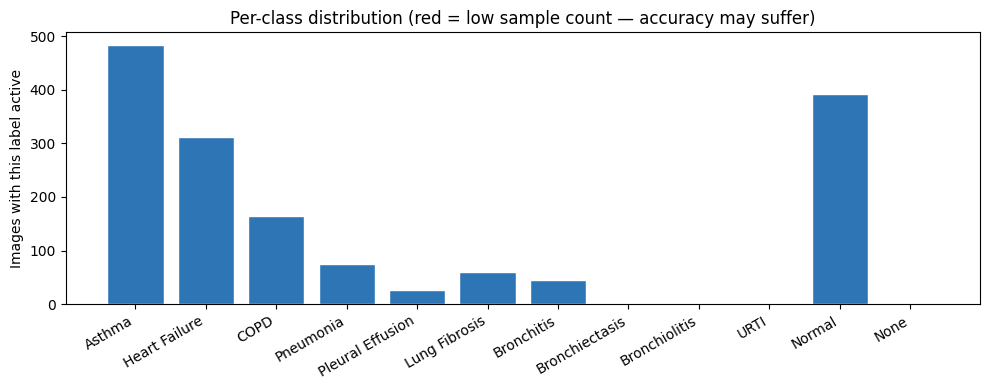

In [138]:
valid_samples = []
skipped_files = []

for fname in sorted(all_files):
    fpath = os.path.join(PNG_DIR, fname)
    label_vec, matched_classes, raw_label = parse_multilabel_vector(fname)

    if label_vec is None or len(matched_classes) == 0:
        skipped_files.append((fname, f"Could not map '{raw_label}' to any class"))
        continue

    valid_samples.append((fpath, label_vec, matched_classes))

print(f"Valid samples   : {len(valid_samples)}")
print(f"Skipped files   : {len(skipped_files)}")

if skipped_files:
    print("\nSkipped files:")
    for fname, reason in skipped_files[:10]:
        print(f"  {fname}  — {reason}")
    if len(skipped_files) > 10:
        print(f"  ... and {len(skipped_files) - 10} more")

# ── Per-class counts ──────────────────────────────────────────────────────────
class_totals = torch.zeros(NUM_CLASSES)
multi_label_count = 0

for _, vec, classes in valid_samples:
    class_totals += vec
    if vec.sum() > 1:
        multi_label_count += 1

print(f"\nCompound/multi-label samples: {multi_label_count}")
print(f"\nPer-class positive sample counts:")
for i, cls in enumerate(CLASSES):
    count = int(class_totals[i].item())
    flag = "  ← LOW" if 0 < count < 15 else ""
    print(f"  {cls:<20}: {count:>4}{flag}")

# Plot
plt.figure(figsize=(10, 4))
counts_list = [int(class_totals[i].item()) for i in range(NUM_CLASSES)]
colors = ['#C0392B' if c < 15 else '#2E75B6' for c in counts_list]
plt.bar(CLASSES, counts_list, color=colors, edgecolor='white')
plt.xticks(rotation=30, ha='right')
plt.ylabel("Images with this label active")
plt.title("Per-class distribution (red = low sample count — accuracy may suffer)")
plt.tight_layout()
plt.show()

In [139]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class MultiLabelSpectrogramDataset(Dataset):
    """
    Returns (image_tensor, metadata_tensor, label_vector) per sample.
      image_tensor : (3, 224, 224)  float32
      metadata     : (2,)           float32  [age_norm, gender]
      label_vector : (NUM_CLASSES,) float32  binary 0/1 per disease
    """
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fpath, label_vec, _ = self.samples[idx]
        img = Image.open(fpath).convert('RGB')
        if self.transform:
            img = self.transform(img)
        age_norm, gender = parse_age_gender(os.path.basename(fpath))
        metadata = torch.tensor([age_norm, gender], dtype=torch.float32)
        return img, metadata, label_vec

In [140]:
import random
random.seed(42)
random.shuffle(valid_samples)

n         = len(valid_samples)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_samples = valid_samples[:train_end]
val_samples   = valid_samples[train_end:val_end]
test_samples  = valid_samples[val_end:]

train_dataset = MultiLabelSpectrogramDataset(train_samples, transform=train_transforms)
val_dataset   = MultiLabelSpectrogramDataset(val_samples,   transform=val_transforms)
test_dataset  = MultiLabelSpectrogramDataset(test_samples,  transform=val_transforms)

print(f"Train samples : {len(train_samples)}")
print(f"Val samples   : {len(val_samples)}")
print(f"Test samples  : {len(test_samples)}")

# Count positives per class in training set
train_label_matrix = torch.stack([s[1] for s in train_samples])  # (N_train, 9)
pos_counts = train_label_matrix.sum(dim=0)                        # (9,) — positives per class
neg_counts = len(train_samples) - pos_counts                      # (9,) — negatives per class

# Avoid division by zero for classes with 0 positives
pos_counts_safe = pos_counts.clamp(min=1)
pos_weight = neg_counts / pos_counts_safe
pos_weight = pos_weight.to(device)

print("Positive weights per class (higher = rarer in training set):")
for i, cls in enumerate(CLASSES):
    print(f"  {cls:<20}: pos={int(pos_counts[i]):>4}  neg={int(neg_counts[i]):>4}  "
          f"pos_weight={pos_weight[i]:.2f}")

Train samples : 1089
Val samples   : 234
Test samples  : 234
Positive weights per class (higher = rarer in training set):
  Asthma              : pos= 345  neg= 744  pos_weight=2.16
  Heart Failure       : pos= 210  neg= 879  pos_weight=4.19
  COPD                : pos= 119  neg= 970  pos_weight=8.15
  Pneumonia           : pos=  50  neg=1039  pos_weight=20.78
  Pleural Effusion    : pos=  20  neg=1069  pos_weight=53.45
  Lung Fibrosis       : pos=  39  neg=1050  pos_weight=26.92
  Bronchitis          : pos=  30  neg=1059  pos_weight=35.30
  Bronchiectasis      : pos=   0  neg=1089  pos_weight=1089.00
  Bronchiolitis       : pos=   0  neg=1089  pos_weight=1089.00
  URTI                : pos=   0  neg=1089  pos_weight=1089.00
  Normal              : pos= 276  neg= 813  pos_weight=2.95
  None                : pos=   0  neg=1089  pos_weight=1089.00


In [141]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

# Confirm shapes
imgs_b, meta_b, labels_b = next(iter(train_loader))
print(f"Batch image shape    : {imgs_b.shape}")    # [32, 3, 224, 224]
print(f"Batch metadata shape : {meta_b.shape}")    # [32, 2]
print(f"Batch label shape    : {labels_b.shape}")  # [32, NUM_CLASSES]
print(f"Batch label dtype    : {labels_b.dtype}")  # torch.float32

Batch image shape    : torch.Size([32, 3, 224, 224])
Batch metadata shape : torch.Size([32, 2])
Batch label shape    : torch.Size([32, 12])
Batch label dtype    : torch.float32


In [142]:
# Create model
model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

in_features = model.classifier[1].in_features   # 1280

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features, NUM_CLASSES)   # 1280 → 9 raw logits
    # NO sigmoid here — BCEWithLogitsLoss applies it internally
    # for numerical stability
)

model = model.to(device)

# Verify output shape
with torch.no_grad():
    dummy = torch.randn(1, 3, 224, 224).to(device)
    out = model(dummy)
    print(f"Output shape: {out.shape}")   # [1, 9]
    print(f"Output (raw logits): {out[0].cpu().numpy().round(2)}")
    # These are unbounded — sigmoid will convert to (0,1) per class

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

class MetadataWeightNet(nn.Module):
    def __init__(self, meta_dim=2, num_classes=NUM_CLASSES):
        super().__init__()
        self.importance = nn.Sequential(
            nn.Linear(meta_dim, 16),
            nn.ReLU(),
            nn.Linear(16, meta_dim),
            nn.Softmax(dim=-1),         # → importance weight per feature (sums to 1)
        )
        self.projection = nn.Linear(meta_dim, num_classes)   # → logit offset

    def forward(self, metadata):
        """
        metadata : (B, 2)  — [age_norm, gender]
        returns  : (B, NUM_CLASSES)  — additive logit offset for each disease
        """
        weights          = self.importance(metadata)    # (B, 2)  importance scores
        self.last_weights = weights                     # saved for inspection after training
        weighted         = metadata * weights           # (B, 2)  scale each feature
        return self.projection(weighted)                # (B, NUM_CLASSES)

meta_model = MetadataWeightNet().to(device)

# Print a quick summary
print(f"MetadataWeightNet params: {sum(p.numel() for p in meta_model.parameters())}")

Output shape: torch.Size([1, 12])
Output (raw logits): [ 0.01  0.02 -0.08 -0.02 -0.17  0.09 -0.16  0.02  0.12  0.13 -0.05  0.04]
Total params    : 4,022,920
Trainable params: 4,022,920
MetadataWeightNet params: 118


In [143]:
# BCEWithLogitsLoss for multi-label classification
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# Internally applies sigmoid per class, then computes binary cross-entropy
# Expects: logits of shape (B, 9) and targets of shape (B, 9) with 0.0/1.0 values

optimizer = optim.AdamW(
    list(filter(lambda p: p.requires_grad, model.parameters())) +
    list(meta_model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

def run_epoch(loader, is_train):
    """
    One full pass over the dataset.
    Returns: (avg_loss, exact_match_accuracy, all_preds, all_targets)
    """
    model.train()      if is_train else model.eval()
    meta_model.train() if is_train else meta_model.eval()

    total_loss    = 0.0
    exact_correct = 0
    total         = 0
    all_preds_list, all_targets_list = [], []

    for imgs, metadata, label_vecs in loader:       # ← 3-tuple now
        imgs       = imgs.to(device)
        metadata   = metadata.to(device)            # (B, 2)
        label_vecs = label_vecs.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            cnn_logits   = model(imgs)              # (B, NUM_CLASSES) from EfficientNet
            meta_offset  = meta_model(metadata)     # (B, NUM_CLASSES) from MetadataWeightNet
            logits       = cnn_logits + meta_offset  # fused prediction
            loss         = criterion(logits, label_vecs)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss    += loss.item() * imgs.size(0)
        preds          = (torch.sigmoid(logits) >= THRESHOLD).float()
        exact_correct += (preds == label_vecs).all(dim=1).sum().item()
        total         += imgs.size(0)

        all_preds_list.append(preds.cpu())
        all_targets_list.append(label_vecs.cpu())

    all_preds   = torch.cat(all_preds_list,   dim=0)
    all_targets = torch.cat(all_targets_list, dim=0)

    return total_loss / total, exact_correct / total, all_preds, all_targets

In [144]:
# Training Loop
NUM_EPOCHS     = 30
SAVE_PATH      = "/content/efficientnet_pulmoscan_multilabel.pth"
SAVE_PATH_META = "/content/metadata_weight_net.pth"

THRESHOLD = 0.5

best_val_loss = float('inf')
history = {"train_loss": [], "val_loss": [], "val_exact_acc": []}

print(f"Starting training — {NUM_EPOCHS} epochs")
print(f"Saving best model to: {SAVE_PATH}")
print(f"Threshold for positive prediction: sigmoid > {THRESHOLD}")
print("-" * 70)
print(f"{'Epoch':<8} {'Train Loss':<14} {'Val Loss':<12} {'Exact Match':<14} {'Status'}")
print("-" * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, _, _, _               = run_epoch(train_loader, is_train=True)
    val_loss, val_exact, val_p, val_t = run_epoch(val_loader,   is_train=False)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_exact_acc"].append(val_exact)

    status = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), SAVE_PATH)
        torch.save(meta_model.state_dict(), SAVE_PATH_META)
        status = "saved"

    print(f"{epoch:<8} {train_loss:<14.4f} {val_loss:<12.4f} "
          f"{val_exact*100:<14.1f}% {status}")

print("-" * 70)
print(f"Training complete. Best val loss: {best_val_loss:.4f}")

# Learned metadata importance
print("\n" + "=" * 60)
print("LEARNED METADATA IMPORTANCE (averaged over val set)")
print("=" * 60)
meta_model.eval()
all_weights = []
with torch.no_grad():
    for _, metadata, _ in val_loader:
        metadata = metadata.to(device)
        meta_model(metadata)
        all_weights.append(meta_model.last_weights.cpu())
avg = torch.cat(all_weights, dim=0).mean(dim=0)
print(f"  Age importance   : {avg[0].item()*100:.1f}%")
print(f"  Gender importance: {avg[1].item()*100:.1f}%")
print("  (softmax — both sum to 100%)")

Starting training — 30 epochs
Saving best model to: /content/efficientnet_pulmoscan_multilabel.pth
Threshold for positive prediction: sigmoid > 0.5
----------------------------------------------------------------------
Epoch    Train Loss     Val Loss     Exact Match    Status
----------------------------------------------------------------------
1        0.9976         0.8889       0.9           % saved
2        0.8438         0.7837       5.6           % saved
3        0.7315         0.7060       4.3           % saved
4        0.6657         0.6272       5.6           % saved
5        0.6169         0.6023       7.7           % saved
6        0.5770         0.5440       5.6           % saved
7        0.5258         0.5116       10.3          % saved
8        0.4885         0.5053       12.4          % saved
9        0.4506         0.4383       14.1          % saved
10       0.4160         0.4497       10.7          % 
11       0.3788         0.3932       26.5          % saved
12     

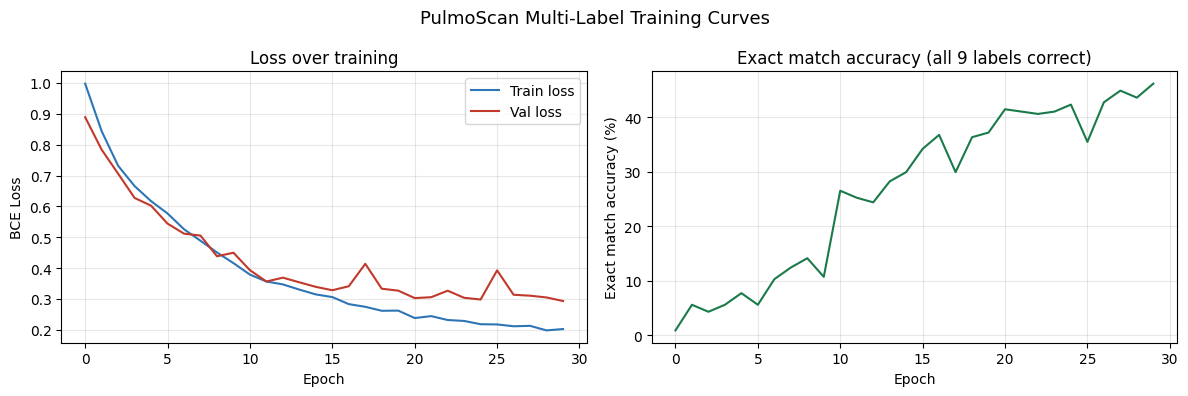

In [149]:
# Training Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train loss", color="#2E75B6")
axes[0].plot(history["val_loss"],   label="Val loss",   color="#C0392B")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Loss over training")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot([a * 100 for a in history["val_exact_acc"]], color="#1A7A4A")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Exact match accuracy (%)")
axes[1].set_title("Exact match accuracy (all 9 labels correct)")
axes[1].grid(alpha=0.3)

plt.suptitle("PulmoScan Multi-Label Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

Per-class performance on validation set:
----------------------------------------------------------------------
                  precision    recall  f1-score   support

          Asthma       0.62      0.86      0.72        74
   Heart Failure       0.73      0.86      0.79        56
            COPD       0.49      0.91      0.63        22
       Pneumonia       0.33      0.75      0.46         8
Pleural Effusion       0.57      1.00      0.73         4
   Lung Fibrosis       0.67      0.80      0.73        10
      Bronchitis       0.53      1.00      0.70         8
  Bronchiectasis       0.00      0.00      0.00         0
   Bronchiolitis       0.00      0.00      0.00         0
            URTI       0.00      0.00      0.00         0
          Normal       0.52      0.83      0.64        52
            None       0.00      0.00      0.00         0

       micro avg       0.58      0.86      0.69       234
       macro avg       0.37      0.58      0.45       234
    weighted avg

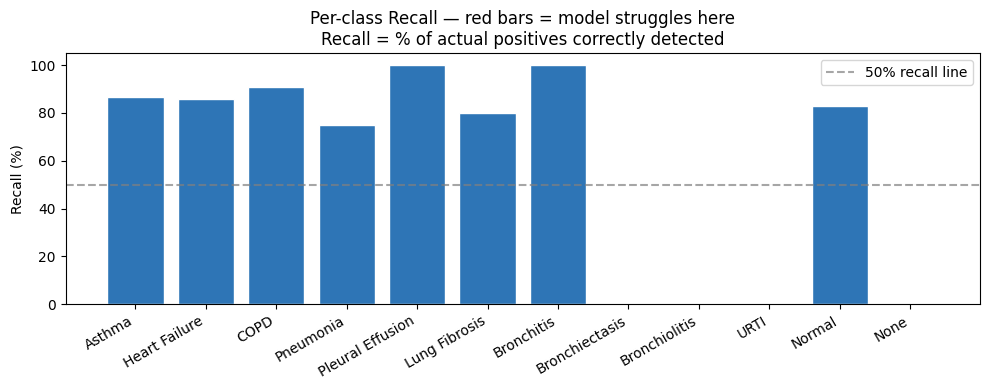

In [146]:
# Evaluation
# Reload best model
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
meta_model.load_state_dict(torch.load(SAVE_PATH_META, map_location=device))
_, _, all_preds, all_targets = run_epoch(val_loader, is_train=False)

# Per-class report
print("Per-class performance on validation set:")
print("-" * 70)
all_preds_np   = all_preds.numpy().astype(int)
all_targets_np = all_targets.numpy().astype(int)

print(classification_report(
    all_targets_np,
    all_preds_np,
    target_names=CLASSES,
    zero_division=0
))

# ── Per-class recall bar chart ────────────────────────────────────────────────
from sklearn.metrics import recall_score
per_class_recall = recall_score(all_targets_np, all_preds_np, average=None, zero_division=0)

plt.figure(figsize=(10, 4))
bar_colors = ['#C0392B' if r < 0.5 else '#2E75B6' for r in per_class_recall]
plt.bar(CLASSES, per_class_recall * 100, color=bar_colors, edgecolor='white')
plt.axhline(y=50, color='gray', linestyle='--', alpha=0.7, label='50% recall line')
plt.xticks(rotation=30, ha='right')
plt.ylabel("Recall (%)")
plt.title("Per-class Recall — red bars = model struggles here\n"
          "Recall = % of actual positives correctly detected")
plt.legend()
plt.tight_layout()
plt.show()

In [160]:
#Inference
INFERENCE_THRESHOLD = 0.5

def predict_single_png(image_path, age, gender_str, threshold=INFERENCE_THRESHOLD):
    """
    Run inference on one PNG.
      image_path : path to any spectrogram PNG (filename ignored)
      age        : integer, e.g. 54
      gender_str : 'M' or 'F'

    Returns list of (disease, confidence_pct) sorted highest first.
    """
    model.eval()
    meta_model.eval()

    img    = Image.open(image_path).convert('RGB')
    tensor = val_transforms(img).unsqueeze(0).to(device)

    age_norm = age / 100.0
    gender   = 1.0 if gender_str.upper() == 'M' else 0.0
    metadata = torch.tensor([[age_norm, gender]], dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = model(tensor) + meta_model(metadata)
        probs  = torch.sigmoid(logits).squeeze(0)

    return sorted(
        [(CLASSES[i], round(probs[i].item() * 100, 1)) for i in range(NUM_CLASSES)],
        key=lambda x: -x[1]
    )


def print_prediction(scores, threshold=INFERENCE_THRESHOLD):
    print(f"\n{'Disease':<22} {'Confidence':>10}   Bar")
    print("-" * 65)
    for cls, pct in scores:
        bar    = "█" * int(pct / 2.5)
        flag   = "  <- PREDICTED" if pct >= threshold * 100 else ""
        print(f"  {cls:<20}: {pct:>6.1f}%   {bar}{flag}")
    predicted = [cls for cls, pct in scores if pct >= threshold * 100]
    print(f"\nPredicted: {predicted if predicted else ['None above threshold']}")
    print("Note: scores are independent and do not sum to 100%")


# ── Manual inference cell — run this on its own whenever you want to test ─────
from google.colab import files as colab_files

patient_age    = 45        # <-- change this
patient_gender = 'M'       # <-- change this: 'M' or 'F'

print(f"Upload a spectrogram PNG (filename doesn't matter).")
uploaded_inf = colab_files.upload()

for fname, data in uploaded_inf.items():
    tmp = f"/content/inf_tmp.png"
    with open(tmp, 'wb') as f:
        f.write(data)
    print(f"\nPrediction for: {fname}  |  age={patient_age}, gender={patient_gender}")
    scores = predict_single_png(tmp, age=patient_age, gender_str=patient_gender)
    print_prediction(scores)

Upload a spectrogram PNG (filename doesn't matter).


Saving EP8_1241_70_M_Plueral_Effusion_pitchshift.png to EP8_1241_70_M_Plueral_Effusion_pitchshift (2).png

Prediction for: EP8_1241_70_M_Plueral_Effusion_pitchshift (2).png  |  age=45, gender=M

Disease                Confidence   Bar
-----------------------------------------------------------------
  Pleural Effusion    :   93.7%   █████████████████████████████████████  <- PREDICTED
  Heart Failure       :   80.2%   ████████████████████████████████  <- PREDICTED
  Normal              :   16.9%   ██████
  Pneumonia           :   16.4%   ██████
  Bronchitis          :    7.8%   ███
  Asthma              :    5.3%   ██
  COPD                :    0.3%   
  Lung Fibrosis       :    0.1%   
  Bronchiectasis      :    0.1%   
  Bronchiolitis       :    0.0%   
  URTI                :    0.0%   
  None                :    0.0%   

Predicted: ['Pleural Effusion', 'Heart Failure']
Note: scores are independent and do not sum to 100%


In [154]:
# Model Summary
from torchinfo import summary

print("EfficientNet-B0 — PulmoScan Multi-Label (9 classes)")
print("=" * 60)
summary(
    model,
    input_size=(1, 3, 224, 224),
    device=device,
    col_names=["output_size", "num_params", "trainable"],
    depth=2
)

EfficientNet-B0 — PulmoScan Multi-Label (9 classes)


Layer (type:depth-idx)                                  Output Shape              Param #                   Trainable
EfficientNet                                            [1, 12]                   --                        True
├─Sequential: 1-1                                       [1, 1280, 7, 7]           --                        True
│    └─Conv2dNormActivation: 2-1                        [1, 32, 112, 112]         928                       True
│    └─Sequential: 2-2                                  [1, 16, 112, 112]         1,448                     True
│    └─Sequential: 2-3                                  [1, 24, 56, 56]           16,714                    True
│    └─Sequential: 2-4                                  [1, 40, 28, 28]           46,640                    True
│    └─Sequential: 2-5                                  [1, 80, 14, 14]           242,930                   True
│    └─Sequential: 2-6                                  [1, 112, 14, 14]          543,148  

In [153]:
# Download weights
from google.colab import files as colab_files

download = input("Download model weights? (y/n): ").strip().lower()
if download == 'y':
    colab_files.download(SAVE_PATH)
    colab_files.download(SAVE_PATH_META)
    print("Download triggered for both weight files.")
else:
    print("Skipped. Files are still available at:")
    print(f"  {SAVE_PATH}")
    print(f"  {SAVE_PATH_META}")

Download model weights? (y/n): y


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered for both weight files.
